Octavio Quintero Flores

266226

### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/ClassFiles/insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Tipos de datos

age, bmi, charges → numéricos
sex, smoker, region → categóricos

charges
Media: ~13,270
Mediana: ~9,382

La media es mucho mayor que la mediana, distribución sesgada a la derecha

Máximo: 63,770
Mínimo: 1,121

Hay valores muy altos → outliers importantes


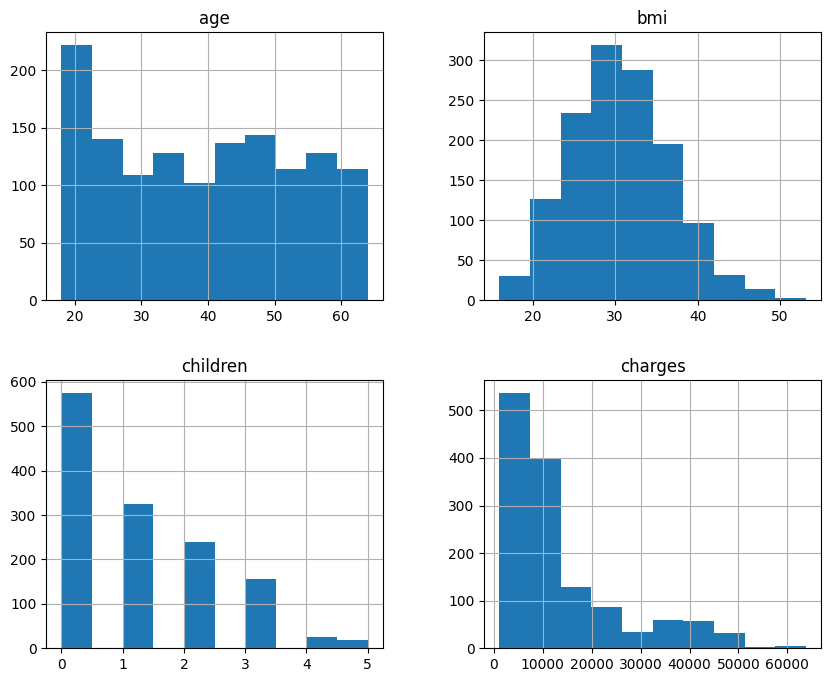

In [7]:
df.hist(figsize=(10,8))
plt.show()

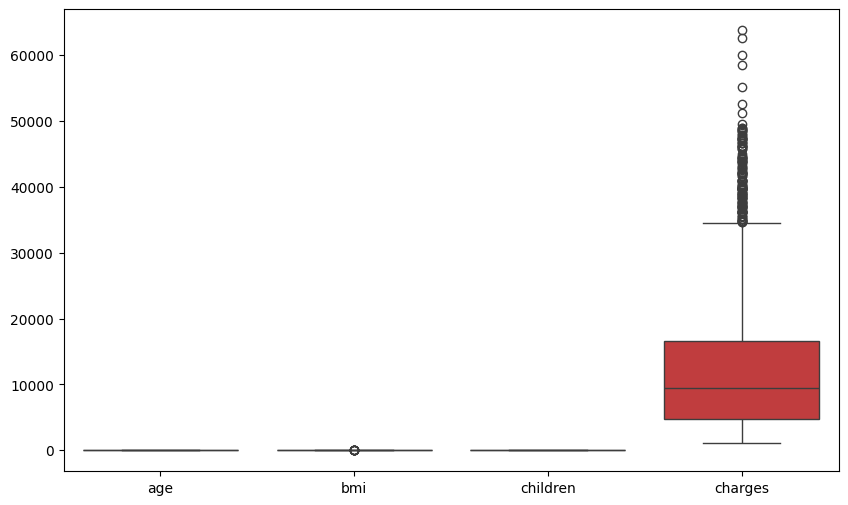

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

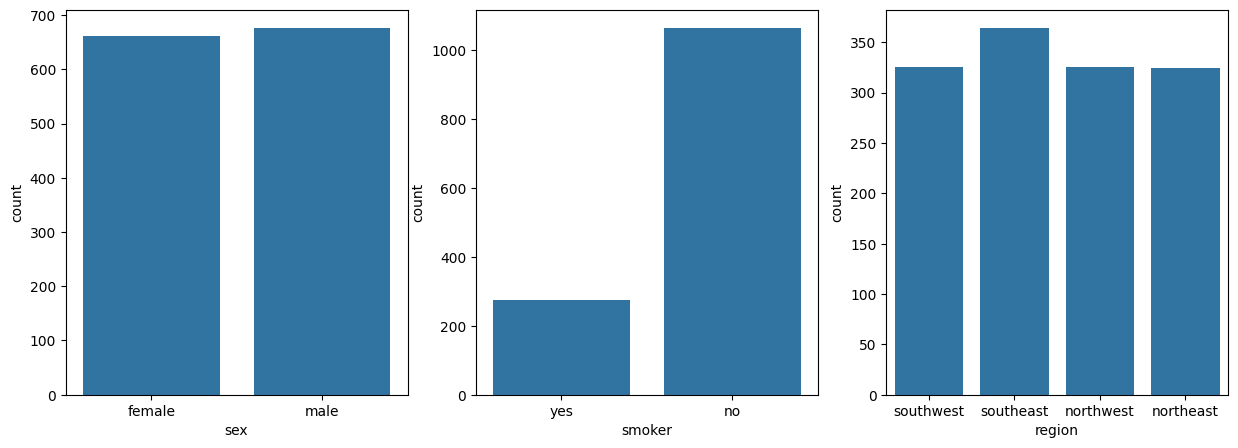

In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(x='sex', data=df, ax=axes[0])
sns.countplot(x='smoker', data=df, ax=axes[1])
sns.countplot(x='region', data=df, ax=axes[2])

plt.show()

1¿charges está muy sesgado?

Sí, fuertemente sesgado a la derecha

2. ¿Ves muchos outliers?

Sí, especialmente en charges
Es la variable más problemática

3. ¿Diferencia en smoker?

Muchísimos no fumadores
Pocos fumadores



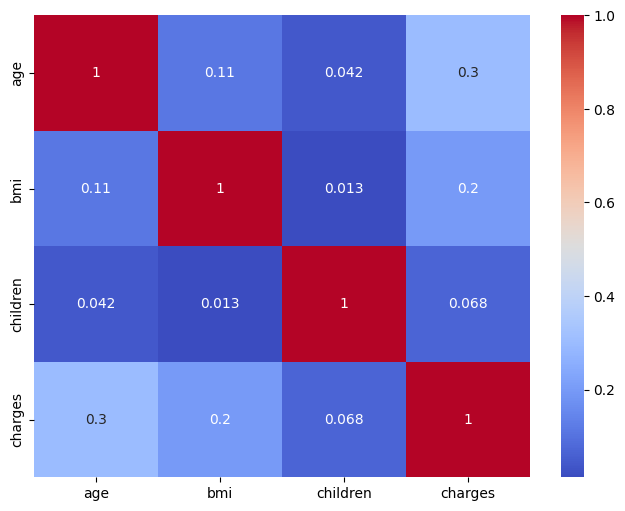

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Relación positiva moderada

A mayor edad → mayor costo médico


La variable con mayor correlación numérica con charges es age, seguida por bmi. Sin embargo, estas correlaciones son moderadas, lo que sugiere que el costo médico no depende únicamente de estas variables. La variable children muestra una relación muy débil. Es importante notar que variables categóricas como smoker, que no aparecen en esta matriz, pueden tener un impacto mucho mayor en el modelo.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separar variables
X = df.drop('charges', axis=1)
y = df['charges']

# Columnas
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# Transformaciones
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Aplicar transformación
X_processed = preprocessor.fit_transform(X)

In [12]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_processed, y)

y_pred_ridge = ridge.predict(X_processed)

mse_ridge = mean_squared_error(y, y_pred_ridge)
r2_ridge = r2_score(y, y_pred_ridge)

print("Ridge MSE:", mse_ridge)
print("Ridge R2:", r2_ridge)

Ridge MSE: 36503887.631331325
Ridge R2: 0.7508994233916109


In [14]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_processed, y)

y_pred_lasso = lasso.predict(X_processed)

mse_lasso = mean_squared_error(y, y_pred_lasso)
r2_lasso = r2_score(y, y_pred_lasso)

print("Lasso MSE:", mse_lasso)
print("Lasso R2:", r2_lasso)

Lasso MSE: 36501893.680594906
Lasso R2: 0.7509130300047799


In [15]:
# Obtener nombres de columnas después de OneHot
ohe = preprocessor.named_transformers_['cat']['onehot']
cat_names = ohe.get_feature_names_out(cat_cols)

feature_names = num_cols + list(cat_names)

In [16]:
coef_ridge = pd.DataFrame({
    'Variable': feature_names,
    'Coef': ridge.coef_
})

print(coef_ridge)

           Variable          Coef
0               age   3604.096982
1               bmi   2064.858647
2          children    573.073125
3          sex_male   -124.200613
4        smoker_yes  23737.991359
5  region_northwest   -347.825073
6  region_southeast  -1018.540799
7  region_southwest   -952.384021


In [17]:
coef_lasso = pd.DataFrame({
    'Variable': feature_names,
    'Coef': lasso.coef_
})

print(coef_lasso)

           Variable          Coef
0               age   3607.401538
1               bmi   2067.477362
2          children    572.886518
3          sex_male   -130.858174
4        smoker_yes  23847.874359
5  region_northwest   -351.296712
6  region_southeast  -1033.232029
7  region_southwest   -958.345589


Conclusiones

Ambos modelos funcionan casi igual

Lasso es ligeramente mejor

Ridge es más estable

smoker domina completamente el modelo

Aunque Lasso tiene la capacidad de eliminar variables irrelevantes, en este caso no llevó ningún coeficiente a cero debido a que el valor de alpha es bajo. Esto indica que todas las variables aportan, aunque sea mínimamente, al modelo.

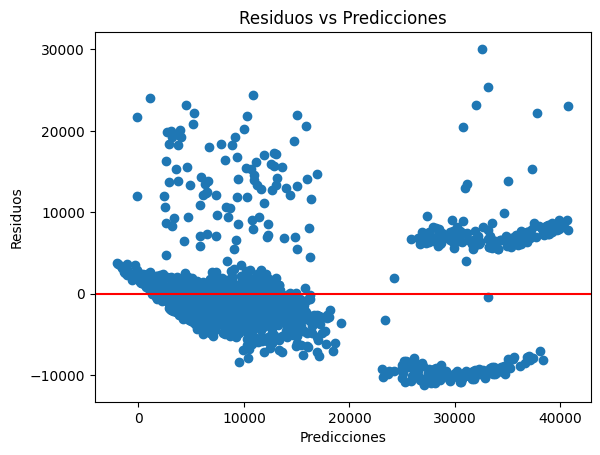

In [18]:
residuals = y - y_pred_ridge

plt.scatter(y_pred_ridge, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicciones")
plt.show()

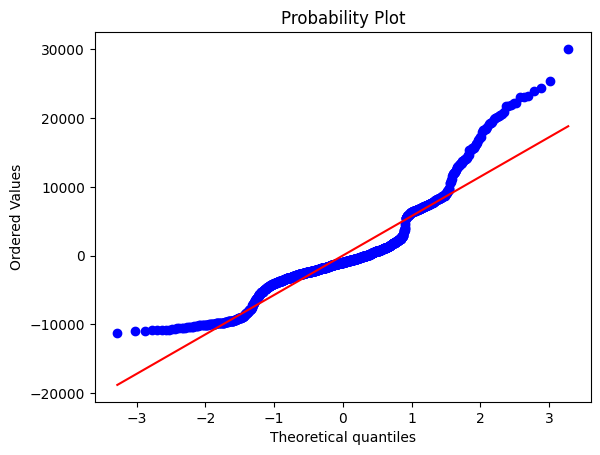

In [19]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

In [20]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)
print("p-value:", p)

p-value: 6.458843138896771e-29


In [21]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_sm = sm.add_constant(X_processed)
test = het_breuschpagan(residuals, X_sm)

print("p-value:", test[1])

p-value: 1.1511217628166822e-22


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = feature_names
vif["VIF"] = [variance_inflation_factor(X_processed, i) for i in range(X_processed.shape[1])]

print(vif)

           Variable       VIF
0               age  1.015843
1               bmi  1.088673
2          children  1.003348
3          sex_male  1.674830
4        smoker_yes  1.228075
5  region_northwest  1.223453
6  region_southeast  1.357419
7  region_southwest  1.215686


El análisis de regresión mediante los modelos Lasso y Ridge muestra que ambos alcanzan un desempeño similar, con un R² cercano a 0.75, lo que indica que explican aproximadamente el 75% de la variabilidad en la variable charges. La variable más influyente en el modelo es smoker, seguida por age y bmi, mientras que variables como children, sex y region tienen un impacto menor.

En cuanto a la regularización, Lasso no eliminó variables debido a un valor bajo del parámetro alpha, lo que sugiere que todas las variables aportan información al modelo. Ridge, por su parte, mantuvo todos los coeficientes reduciendo su magnitud.

Respecto a los supuestos del modelo, se encontró que los residuos no siguen una distribución normal (según el test de Shapiro-Wilk) y presentan heterocedasticidad (según el test de Breusch-Pagan). Sin embargo, no se detectaron problemas de multicolinealidad, ya que todos los valores de VIF fueron bajos.

Estos resultados indican que, aunque el modelo tiene una buena capacidad predictiva, no cumple completamente los supuestos clásicos de regresión lineal. Una posible mejora sería aplicar una transformación logarítmica a la variable objetivo para reducir el sesgo y mejorar el comportamiento de los residuos.